<a href="https://colab.research.google.com/github/rajeshxdatascience/Car-Price-Prediction-ML/blob/main/01_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [115]:
df = pd.read_csv("/content/CAR DETAILS FROM CAR DEKHO.csv")

In [116]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [118]:
df[df.duplicated()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
13,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
14,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
15,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
16,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
17,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4307,Mahindra Xylo H4,2019,599000,15000,Diesel,Individual,Manual,Third Owner
4308,Maruti Alto 800 LXI,2018,200000,35000,Petrol,Individual,Manual,First Owner
4309,Datsun GO Plus T,2017,350000,10171,Petrol,Dealer,Manual,First Owner
4310,Renault Duster 110PS Diesel RxL,2015,465000,41123,Diesel,Dealer,Manual,First Owner


In [119]:
df.drop_duplicates(inplace=True)

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3577 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           3577 non-null   object
 1   year           3577 non-null   int64 
 2   selling_price  3577 non-null   int64 
 3   km_driven      3577 non-null   int64 
 4   fuel           3577 non-null   object
 5   seller_type    3577 non-null   object
 6   transmission   3577 non-null   object
 7   owner          3577 non-null   object
dtypes: int64(3), object(5)
memory usage: 251.5+ KB


In [121]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [122]:
df['name'].value_counts()

,count
name,
Maruti Swift Dzire VDI,54
Maruti Alto 800 LXI,48
Maruti Alto LXi,42
Maruti Alto LX,30
Maruti Swift VDI BSIV,28
...,...
Tata Indica V2 DLS BSII,1
Mahindra XUV500 W10 AWD,1
Toyota Fortuner 2.7 2WD AT,1


In [123]:
df['brand'] = df['name'].str.lower().str.split(' ').str.get(0)

In [124]:
df['brand'].value_counts()

,count
brand,
maruti,1072
hyundai,637
mahindra,328
tata,308
ford,220
honda,216
toyota,170
chevrolet,151
renault,110


In [125]:
brands_counts = df['brand'].value_counts()

rare_brands = brands_counts[brands_counts < 20].index

df['brand'] = df['brand'].replace(rare_brands, 'other')

In [126]:
df['brand'].value_counts()

,count
brand,
maruti,1072
hyundai,637
mahindra,328
tata,308
ford,220
honda,216
toyota,170
chevrolet,151
renault,110


In [127]:
df = df.drop('name', axis=1)

In [128]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,honda


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3577 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   year           3577 non-null   int64 
 1   selling_price  3577 non-null   int64 
 2   km_driven      3577 non-null   int64 
 3   fuel           3577 non-null   object
 4   seller_type    3577 non-null   object
 5   transmission   3577 non-null   object
 6   owner          3577 non-null   object
 7   brand          3577 non-null   object
dtypes: int64(3), object(5)
memory usage: 251.5+ KB


In [130]:
df['car_age'] = 2026 - df['year']

In [131]:
df['car_age'].value_counts()

,count
car_age,
9,346
14,338
11,332
12,321
13,298
8,295
10,283
15,247
16,210


In [132]:
df = df.drop('year',axis=1)

In [133]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,maruti,19
1,135000,50000,Petrol,Individual,Manual,First Owner,maruti,19
2,600000,100000,Diesel,Individual,Manual,First Owner,hyundai,14
3,250000,46000,Petrol,Individual,Manual,First Owner,datsun,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,honda,12


In [134]:
df.duplicated().sum()

np.int64(27)

In [135]:
df.drop_duplicates(inplace=True)

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3550 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   selling_price  3550 non-null   int64 
 1   km_driven      3550 non-null   int64 
 2   fuel           3550 non-null   object
 3   seller_type    3550 non-null   object
 4   transmission   3550 non-null   object
 5   owner          3550 non-null   object
 6   brand          3550 non-null   object
 7   car_age        3550 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 249.6+ KB


In [137]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,maruti,19
1,135000,50000,Petrol,Individual,Manual,First Owner,maruti,19
2,600000,100000,Diesel,Individual,Manual,First Owner,hyundai,14
3,250000,46000,Petrol,Individual,Manual,First Owner,datsun,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,honda,12


In [138]:
df.describe()

,selling_price,km_driven,car_age
count,3.550000e+03,3550.000000,3550.000000
mean,4.746099e+05,69380.056901,13.043099
std,5.108341e+05,47647.754330,4.252141
min,2.000000e+04,1.000000,6.000000
25%,2.000000e+05,36000.000000,10.000000
50%,3.500000e+05,60658.000000,13.000000
75%,6.000000e+05,90000.000000,16.000000
max,8.900000e+06,806599.000000,34.000000


In [139]:
df['selling_price'].value_counts()

,count
selling_price,
300000,134
250000,109
350000,105
500000,86
550000,83
...,...
861999,1
865000,1
696000,1


In [140]:
df['fuel'].value_counts()

,count
fuel,
Diesel,1789
Petrol,1701
CNG,37
LPG,22
Electric,1


In [141]:
df['fuel'] = df['fuel'].replace(['LPG', 'Electric'], 'other')
df['fuel'] = df['fuel'].str.lower()

In [142]:
df['fuel'].value_counts()

,count
fuel,
diesel,1789
petrol,1701
cng,37
other,23


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3550 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   selling_price  3550 non-null   int64 
 1   km_driven      3550 non-null   int64 
 2   fuel           3550 non-null   object
 3   seller_type    3550 non-null   object
 4   transmission   3550 non-null   object
 5   owner          3550 non-null   object
 6   brand          3550 non-null   object
 7   car_age        3550 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 249.6+ KB


In [144]:
df['brand'] = df['brand'].astype('category')
df['fuel'] = df['fuel'].astype('category')

In [145]:
df['seller_type'].value_counts()

,count
seller_type,
Individual,2805
Dealer,712
Trustmark Dealer,33


In [146]:
df['seller_type'] = df['seller_type'].replace('Trustmark Dealer','Dealer')
df['seller_type'] = df['seller_type'].str.lower()
df['seller_type'] = df['seller_type'].astype('category')

In [147]:
df['seller_type'].value_counts()

,count
seller_type,
individual,2805
dealer,745


In [148]:
df['transmission'] = df['transmission'].str.lower()
df['transmission'] = df['transmission'].astype('category')

In [149]:
df['transmission'].value_counts()

,count
transmission,
manual,3238
automatic,312


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3550 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   selling_price  3550 non-null   int64   
 1   km_driven      3550 non-null   int64   
 2   fuel           3550 non-null   category
 3   seller_type    3550 non-null   category
 4   transmission   3550 non-null   category
 5   owner          3550 non-null   object  
 6   brand          3550 non-null   category
 7   car_age        3550 non-null   int64   
dtypes: category(4), int64(3), object(1)
memory usage: 153.7+ KB


In [151]:
df['owner'] = df['owner'].str.lower()

In [152]:
df['owner'].value_counts()

,count
owner,
first owner,2199
second owner,970
third owner,289
fourth & above owner,75
test drive car,17


In [153]:
df['owner'] = df['owner'].replace('test drive car', 'first owner')

In [154]:
df['owner'] = df['owner'].astype('category')

In [155]:
df['owner'].value_counts()

,count
owner,
first owner,2216
second owner,970
third owner,289
fourth & above owner,75


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3550 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   selling_price  3550 non-null   int64   
 1   km_driven      3550 non-null   int64   
 2   fuel           3550 non-null   category
 3   seller_type    3550 non-null   category
 4   transmission   3550 non-null   category
 5   owner          3550 non-null   category
 6   brand          3550 non-null   category
 7   car_age        3550 non-null   int64   
dtypes: category(5), int64(3)
memory usage: 129.6 KB


In [157]:
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,60000,70000,petrol,individual,manual,first owner,maruti,19
1,135000,50000,petrol,individual,manual,first owner,maruti,19
2,600000,100000,diesel,individual,manual,first owner,hyundai,14
3,250000,46000,petrol,individual,manual,first owner,datsun,9
4,450000,141000,diesel,individual,manual,second owner,honda,12


## EDA (Exploratory Data Analysis)

<Axes: ylabel='Frequency'>

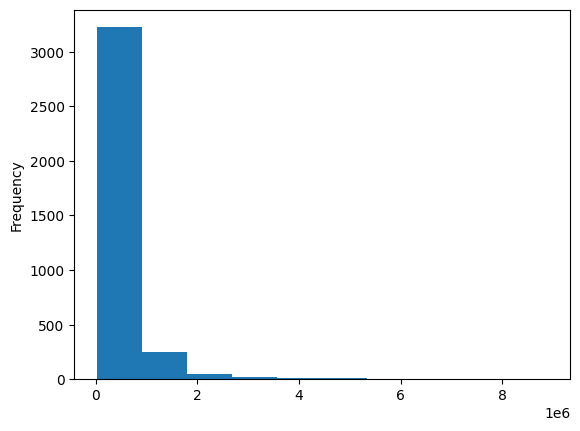

In [160]:
# Univariate analysis on numerical columns

df['selling_price'].plot(kind='hist')

<Axes: ylabel='Density'>

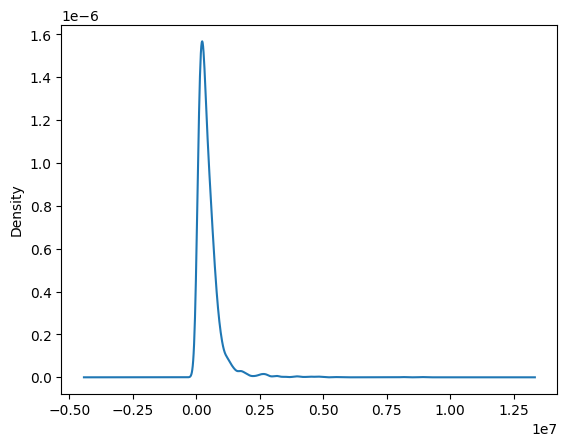

In [162]:
df['selling_price'].plot(kind='kde')

In [163]:
df['selling_price'].skew()

np.float64(5.44234196680351)

<Axes: ylabel='selling_price'>

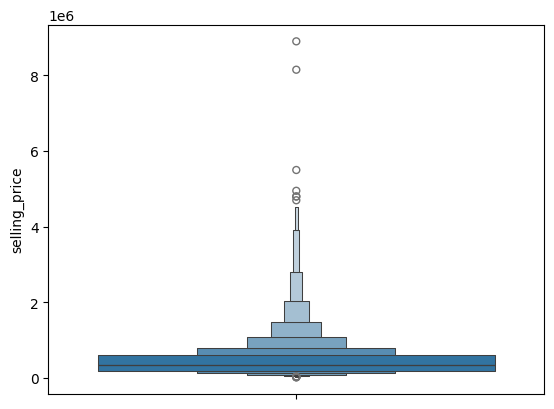

In [169]:
sns.boxenplot(df['selling_price'])

In [168]:
df[df['selling_price'] > 5000000]

,selling_price,km_driven,fuel,seller_type,transmission,owner,brand,car_age
89,8150000,6500,diesel,dealer,automatic,first owner,mercedes-benz,9
3872,8900000,13000,petrol,dealer,automatic,first owner,audi,10
3969,5500000,77350,diesel,dealer,automatic,first owner,mercedes-benz,10


In [165]:
df['selling_price'].describe()

,selling_price
count,3.550000e+03
mean,4.746099e+05
std,5.108341e+05
min,2.000000e+04
25%,2.000000e+05
50%,3.500000e+05
75%,6.000000e+05
max,8.900000e+06


Text(0.5, 1.0, 'Selling price distribution')

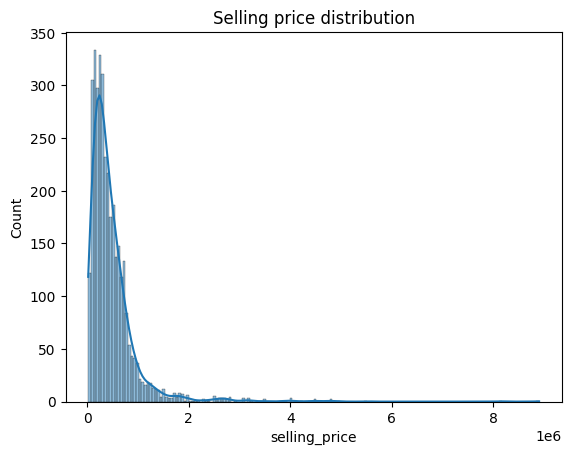

In [167]:
sns.histplot(df['selling_price'], kde=True)
plt.title("Selling price distribution")

In [170]:
# selling_price is right skewed so we use log_price

df['log_price'] = np.log(df['selling_price'])

<Axes: xlabel='log_price', ylabel='Count'>

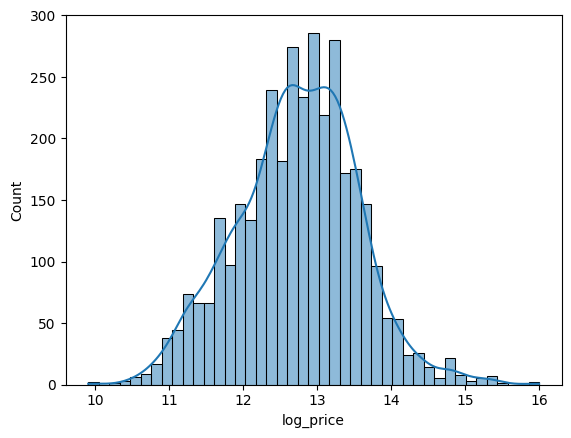

In [171]:
sns.histplot(df['log_price'], kde=True)

In [172]:
df['log_price'].skew()

np.float64(-0.02155164231230296)

<Axes: ylabel='log_price'>

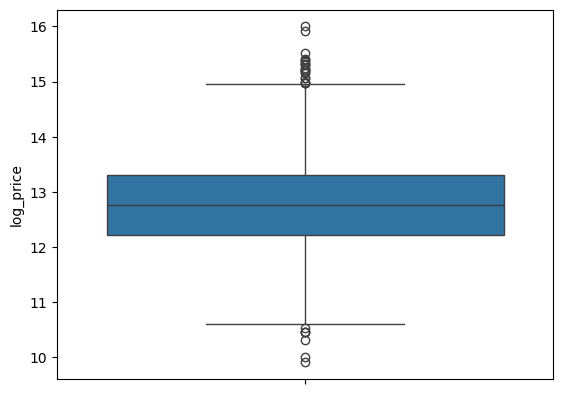

In [183]:
sns.boxplot(df['log_price'])

In [197]:
Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['log_price'] < lower) | (df['log_price'] > upper)]
outliers.shape

(29, 10)

In [198]:
df['log_price'].quantile(0.99)

np.float64(14.799459938312244)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3550 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   selling_price  3550 non-null   int64   
 1   km_driven      3550 non-null   int64   
 2   fuel           3550 non-null   category
 3   seller_type    3550 non-null   category
 4   transmission   3550 non-null   category
 5   owner          3550 non-null   category
 6   brand          3550 non-null   category
 7   car_age        3550 non-null   int64   
 8   log_price      3550 non-null   float64 
dtypes: category(5), float64(1), int64(3)
memory usage: 157.3 KB


<Axes: xlabel='km_driven', ylabel='Count'>

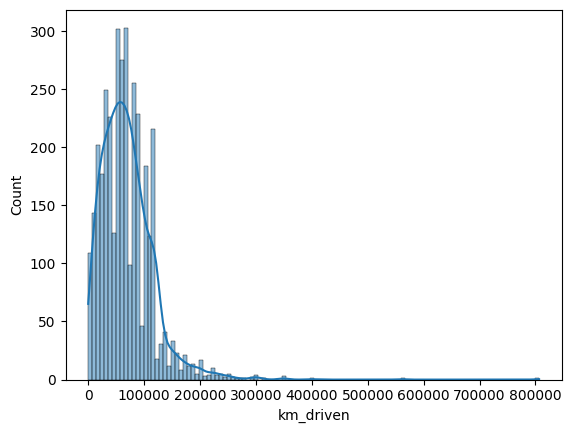

In [174]:
sns.histplot(df['km_driven'], kde=True)

In [175]:
df['km_driven'].skew()

np.float64(2.552268783742781)

<Axes: ylabel='km_driven'>

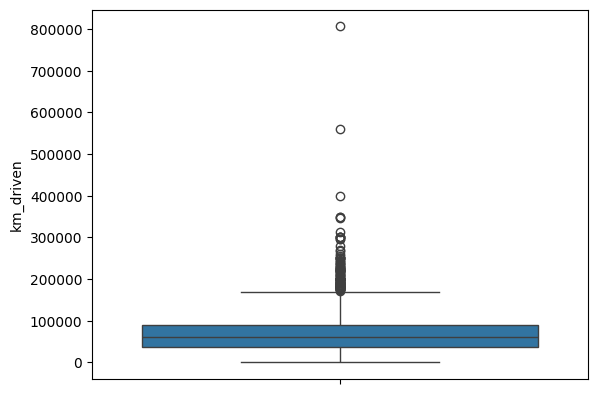

In [177]:
sns.boxplot(df['km_driven'])

In [191]:
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['km_driven'] < lower) | (df['km_driven'] > upper)]
outliers.shape

(106, 10)

In [194]:
upper_limit = df['km_driven'].quantile(0.99)

df['km_driven'] = np.where(df['km_driven'] > upper_limit, upper_limit, df['km_driven'])

<Axes: ylabel='km_driven'>

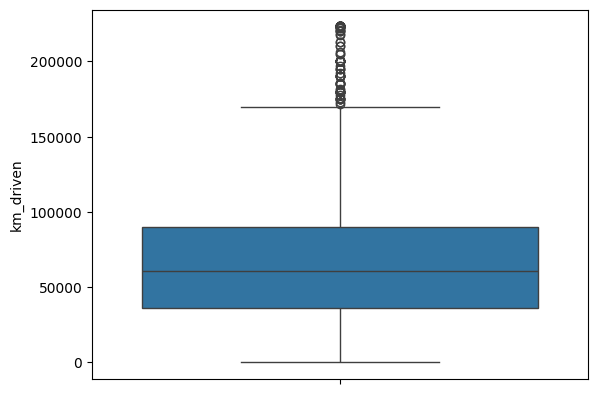

In [196]:
sns.boxplot(df['km_driven'])

In [199]:
df['km_driven'].skew()

np.float64(1.003071677401176)

Text(0.5, 1.0, 'km_driven after outlier capping')

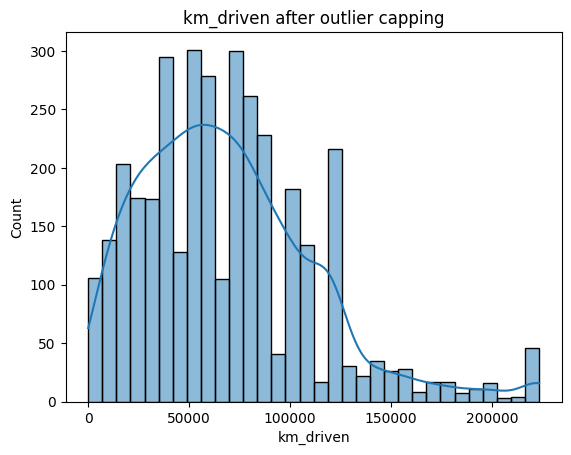

In [200]:
sns.histplot(df['km_driven'], kde=True)
plt.title("km_driven after outlier capping")

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3550 entries, 0 to 4339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   selling_price  3550 non-null   int64   
 1   km_driven      3550 non-null   float64 
 2   fuel           3550 non-null   category
 3   seller_type    3550 non-null   category
 4   transmission   3550 non-null   category
 5   owner          3550 non-null   category
 6   brand          3550 non-null   category
 7   car_age        3550 non-null   int64   
 8   log_price      3550 non-null   float64 
 9   log_km_driven  3550 non-null   float64 
dtypes: category(5), float64(3), int64(2)
memory usage: 185.1 KB
